# 03 — Evaluación del sistema GraphRAG (metodología RAGAS)

Este notebook evalúa el pipeline GraphRAG sobre Sherlock Holmes usando las tres métricas 
**RAGAS**. El enfoque **no** requiere la librería RAGAS — todas las métricas se implementan 
como llamadas estructuradas al LLM (Gemini).

### Las tres métricas

| Métrica | Qué mide | Cómo |
|---|---|---|
| **context_recall** | ¿El recuperador obtuvo chunks que cubren la verdad esperada? | Cada frase del ground truth se verifica: ¿puede atribuirse al contexto recuperado? |
| **faithfulness** | ¿La respuesta contiene solo cosas respaldadas por el contexto? | La respuesta se descompone en afirmaciones atómicas; cada una se verifica contra el contexto. |
| **answer_correctness** | ¿Cuánto se superpone la respuesta con el ground truth? | Las afirmaciones se clasifican en TP / FP / FN; se calcula el F1. |

### El pipeline de evaluación

```
CSV de benchmark
  (question ; cypher)
        │
        ▼
  load_dataset()       ← lee el CSV
        │
        ▼
  run_benchmark()      ← ejecuta Cypher para obtener ground truths dinámicos,
                         llama al agente RAG, registra latencia
        │
        ▼
  evaluate_results()   ← puntúa cada fila con las tres métricas RAGAS
        │
        ▼
  print_summary()      ← tabla agregada
```

**Requisito previo:** Ejecutar `01_ingestion_demo.ipynb` para cargar los datos de Sherlock Holmes en Neo4j.

## 1. Configuración

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from graphrag.graph.neo4j_manager import Neo4jManager
from graphrag.agents import AgenticRAG
from graphrag.evaluation import RAGEvaluator

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

In [2]:
neo4j = Neo4jManager()
rag = AgenticRAG(neo4j)
evaluator = RAGEvaluator(rag, neo4j)
print("Sistema listo.")
print(f"Estado del grafo: {neo4j.get_stats()}")

Sistema listo.
Estado del grafo: {'Event': 412, 'Deduction': 323, 'Object': 269, 'Chunk': 200, 'Scene': 185, 'Location': 85, 'Character': 73, 'Crime': 19, 'Story': 6}


## 2. Inspección de métricas — pregunta a pregunta

Antes de ejecutar el benchmark completo, es instructivo ver qué hace cada métrica
internamente. Tomamos una sola pregunta y llamamos a cada métrica de forma manual.

In [3]:
question     = "¿Dónde vive Sherlock Holmes?"
ground_truth = "Sherlock Holmes vive en el 221B de Baker Street, Londres."

# Preguntamos al agente
answer, context = evaluator.get_answer(question)
print(f"Respuesta       : {answer}")
print(f"Chunks recuperados: {len(context)}")

Respuesta       : Esta información no se encuentra en la base de conocimiento.
Chunks recuperados: 2


In [4]:
# --- context_recall ---
# Objetivo: ¿puede atribuirse cada frase del ground truth al contexto recuperado?
# Puntuación = (frases atribuidas) / (total de frases)  →  rango [0, 1]
recall_result = evaluator.evaluate_context_recall(question, ground_truth, context, verbose=True)

print("context_recall")
print(f"  puntuación : {recall_result.get('recall', 0):.3f}")
print(f"  frases     : {recall_result.get('sentences', [])}")
print(f"  atribuidas : {recall_result.get('attributions', [])}")


── context_recall ──────────────────────────────────
  Question    : ¿Dónde vive Sherlock Holmes?
  Ground truth: Sherlock Holmes vive en el 221B de Baker Street, Londres.
  Context chunks retrieved: 2

  [Step 1] Asking the LLM to attribute each ground-truth sentence to context...

  Ground-truth sentences (0):

  Reasoning : The ground truth states that Sherlock Holmes lives at 221B Baker Street, London. The provided context only lists 'house' and 'Doctors' Commons' as locations, without any mention of Sherlock Holmes, Baker Street, or London. Therefore, the context does not support the ground truth.
  Score     : 0.000
────────────────────────────────────────────────────
context_recall
  puntuación : 0.000
  frases     : []
  atribuidas : []


In [5]:
# --- faithfulness ---
# Paso 1: descomponer la respuesta en afirmaciones atómicas sin pronombres.
# Paso 2: verificar si cada afirmación puede inferirse del contexto.
# Puntuación = (afirmaciones respaldadas) / (total)  →  rango [0, 1]
faith_result = evaluator.evaluate_faithfulness(question, answer, context, verbose=True)

print("faithfulness")
print(f"  puntuación  : {faith_result.get('faithfulness', 0):.3f}")
print(f"  afirmaciones: {faith_result.get('statements', [])}")
print(f"  veredictos  : {faith_result.get('verdicts', [])}")


── faithfulness ────────────────────────────────────
  Question: ¿Dónde vive Sherlock Holmes?
  Answer  : Esta información no se encuentra en la base de conocimiento.

  Answer is a KB-abstention — faithfulness = 1.0 by convention.
────────────────────────────────────────────────────
faithfulness
  puntuación  : 1.000
  afirmaciones: ['Esta información no se encuentra en la base de conocimiento.']
  veredictos  : [1]


In [6]:
# --- answer_correctness ---
# Objetivo: ¿cuánto se superpone la respuesta con el ground truth?
# Se clasifican afirmaciones en TP (correctas), FP (añadidas), FN (faltantes)
# Puntuación = F1-score  →  rango [0, 1]
corr_result = evaluator.evaluate_answer_correctness(question, answer, ground_truth, verbose=True)

print("answer_correctness")
print(f"  F1        : {corr_result.get('answer_correctness', 0):.3f}")
print(f"  TP={corr_result.get('tp', 0)}  FP={corr_result.get('fp', 0)}  FN={corr_result.get('fn', 0)}")


── answer_correctness ──────────────────────────────
  Question    : ¿Dónde vive Sherlock Holmes?
  Answer      : Esta información no se encuentra en la base de conocimiento.
  Ground truth: Sherlock Holmes vive en el 221B de Baker Street, Londres.

  [Step 1] Decomposing the answer into statements...
  Answer statements (1):
    1. The information about where Sherlock Holmes lives is not present in the knowledge base.

  [Step 2] Decomposing the ground truth into statements...
  Ground truth statements (2):
    1. Sherlock Holmes vive en el 221B de Baker Street.
    2. El 221B de Baker Street está en Londres.

  [Step 3] Classifying each statement as TP / FP / FN...
  Classifications:
    [FP] The information about where Sherlock Holmes lives is not present in the knowledge base. — The ground truth explicitly states where Sherlock Holmes lives (221B Baker Street, London), directly contradicting the answer's claim that this information is not present.
    [FN] Sherlock Holmes vive en 

## 3. Evaluación con diferentes tipos de pregunta

Veamos cómo se comportan las métricas con distintos tipos: greeting, out-of-scope,
pregunta factual, pregunta de grafo, etc.

In [7]:
q = "Hello, how are you?"
gt = "Hello! I am a knowledge assistant specialising in Sherlock Holmes stories."

answer, context = evaluator.get_answer(q)
print(f"Q: {q}")
print(f"A: {answer}")
print(f"GT: {gt}")
print(f"Context chunks: {len(context)}\n")

recall = evaluator.evaluate_context_recall(q, gt, context, verbose=True)
faith = evaluator.evaluate_faithfulness(q, answer, context, verbose=True)
corr = evaluator.evaluate_answer_correctness(q, answer, gt, verbose=True)

print(f"\nResumen: recall={recall['recall']:.3f}, faithfulness={faith['faithfulness']:.3f}, correctness={corr['answer_correctness']:.3f}")

Q: Hello, how are you?
A: ¡Hola! Soy un asistente de conocimiento especializado en las historias de Sherlock Holmes de Arthur Conan Doyle. Puedo responder preguntas sobre personajes, ubicaciones, crímenes, deducciones, objetos y eventos de los relatos del canon holmesiano.
GT: Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.
Context chunks: 0


── context_recall ──────────────────────────────────
  Question    : Hello, how are you?
  Ground truth: Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.
  Context chunks retrieved: 0

  [Step 1] No retrieved context detected.
    [✓ attributed] Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.

  Reasoning : No context was retrieved, and the ground truth is a conversational, scope-refusal, or KB-abstention response that requires no knowledge lookup. Recall = 1.0.
  Score     : 1.000
────────────────────────────────────────────────────

── faithfulness ─────────────────

In [8]:
q = "What crimes does Holmes investigate in A Scandal in Bohemia?"
gt_cypher = "MATCH (c:Character {name: 'Sherlock Holmes'})-[:INVESTIGATES]->(cr:Crime {story_title: 'A Scandal in Bohemia'}) RETURN cr.name AS ground_truth"
gt_results = neo4j.execute_query(gt_cypher)
gt = "; ".join([str(r.get('ground_truth', '')) for r in gt_results]) if gt_results else "No crimes found."

answer, context = evaluator.get_answer(q)
print(f"Q: {q}")
print(f"A: {answer}")
print(f"GT (from Cypher): {gt}\n")

recall = evaluator.evaluate_context_recall(q, gt, context)
faith = evaluator.evaluate_faithfulness(q, answer, context)
corr = evaluator.evaluate_answer_correctness(q, answer, gt)

print(f"Resumen: recall={recall['recall']:.3f}, faithfulness={faith['faithfulness']:.3f}, correctness={corr['answer_correctness']:.3f}")

Q: What crimes does Holmes investigate in A Scandal in Bohemia?
A: Holmes investiga el Potencial Escándalo de la Casa de Ormstein [3]. Este caso involucra una fotografía comprometedora y la amenaza de chantaje por parte de Irene Adler [3].
GT (from Cypher): No crimes found.

Resumen: recall=1.000, faithfulness=1.000, correctness=0.000


## 4. Benchmark CSV

El benchmark define pares (pregunta, Cypher). El ground truth se obtiene ejecutando
la query Cypher contra el grafo — así la evaluación es **dinámica** y agnóstica a los datos.

In [9]:
import csv
import os

benchmark_questions = [
    # Greetings y out-of-scope
    ("Hello", "RETURN 'Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.' AS ground_truth"),
    ("What can you do?", "RETURN 'I can answer questions about Sherlock Holmes stories: characters, crimes, deductions, locations, and events.' AS ground_truth"),
    ("What is the weather like today?", "RETURN 'This question is outside my scope.' AS ground_truth"),
    ("Who won the World Cup?", "RETURN 'This question is outside my scope.' AS ground_truth"),
    # Preguntas factuales sobre el grafo
    ("How many stories are in the graph?", "MATCH (s:Story) WITH count(s) AS n RETURN 'There are ' + toString(n) + ' stories in the graph.' AS ground_truth"),
    ("How many characters are in the graph?", "MATCH (c:Character) WITH count(c) AS n RETURN 'There are ' + toString(n) + ' characters in the graph.' AS ground_truth"),
    ("What stories does Sherlock Holmes appear in?", "MATCH (c:Character {name: 'Sherlock Holmes'})-[:APPEARS_IN]->(s:Story) RETURN s.title AS ground_truth ORDER BY s.title"),
    ("Who does Holmes know?", "MATCH (c:Character {name: 'Sherlock Holmes'})-[:KNOWS]->(c2:Character) RETURN c2.name AS ground_truth ORDER BY c2.name"),
    ("What crimes does Holmes investigate?", "MATCH (c:Character {name: 'Sherlock Holmes'})-[:INVESTIGATES]->(cr:Crime) RETURN cr.name AS ground_truth"),
    ("Where does Holmes live?", "MATCH (c:Character {name: 'Sherlock Holmes'})-[:LIVES_AT]->(l:Location) RETURN l.name AS ground_truth"),
    ("How many locations are in the graph?", "MATCH (l:Location) WITH count(l) AS n RETURN 'There are ' + toString(n) + ' locations in the graph.' AS ground_truth"),
    # Preguntas semánticas
    ("Describe Holmes' deduction method", "MATCH (d:Deduction) RETURN d.method AS ground_truth LIMIT 3"),
    ("What happens at Baker Street?", "MATCH (sc:Scene)-[:TAKES_PLACE_IN]->(l:Location) WHERE l.name CONTAINS 'Baker' RETURN sc.title AS ground_truth"),
]

os.makedirs('../data', exist_ok=True)
benchmark_path = '../data/benchmark_sherlock.csv'

with open(benchmark_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f, delimiter=';')
    writer.writerow(['question', 'cypher'])
    for q, c in benchmark_questions:
        writer.writerow([q, c])

print(f"Benchmark guardado: {benchmark_path} ({len(benchmark_questions)} preguntas)")

Benchmark guardado: ../data/benchmark_sherlock.csv (13 preguntas)


In [10]:
dataset = evaluator.load_dataset(benchmark_path)
print(f"Benchmark CSV: {len(dataset)} preguntas")
dataset[['question']]

Benchmark CSV: 13 preguntas


,question
0,Hello
1,What can you do?
2,What is the weather like today?
3,Who won the World Cup?
4,How many stories are in the graph?
5,How many characters are in the graph?
6,What stories does Sherlock Holmes appear in?
7,Who does Holmes know?
8,What crimes does Holmes investigate?
9,Where does Holmes live?


## 5. Ejecutar benchmark completo

⚠️ **Nota:** La ejecución completa tarda varios minutos (una llamada LLM por pregunta +
3 llamadas LLM por métrica × N preguntas). Descomenta para ejecutar.

In [11]:
# Ejecutar el pipeline completo
results_df = evaluator.run_benchmark(dataset, verbose=True)
scored_df = evaluator.evaluate_results(results_df, verbose=True)
evaluator.print_summary(scored_df)

Processing rows:   0%|          | 0/13 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [1/13] Hello
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN 'Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.' AS ground_truth
  Ground truth: Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.

  [Step 2] Calling the RAG agent...


Processing rows:   8%|▊         | 1/13 [00:05<01:05,  5.50s/it]

  Answer  : ¡Hola! Soy un asistente de conocimiento especializado en las historias de Sherlock Holmes de Arthur Conan Doyle. Puedo responder preguntas sobre personajes, ubicaciones, crímenes, deducciones, objetos y eventos de los relatos del canon holmesiano.
  Context chunks: 0
  Latency : 5.49s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [2/13] What can you do?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN 'I can answer questions about Sherlock Holmes stories: characters, crimes, deductions, locations, and events.' AS ground_truth
  Ground truth: I can answer questions about Sherlock Holmes stories: characters, crimes, deductions, locations, and events.

  [Step 2] Calling the RAG agent...


Processing rows:  15%|█▌        | 2/13 [00:13<01:17,  7.05s/it]

...

  Classifications:
    [FP] The information about Holmes's living place is not found in the knowledge base. — The ground truth explicitly states where Holmes lives ('in a house' and 'in Doctors' Commons'), directly contradicting the answer's claim that this information is not found.

  TP=0  FP=1  FN=0
  Precision=0.000  Recall=0.000  F1=0.000
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: How many locations are in the graph?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : How many locations are in the graph?
  Ground truth: There are 85 locations in the graph.
  Context chunks retrieved: 1

  [Step 1] Asking the LLM to attribute each ground-truth sentence to context...

  Ground-truth sentences (1):
    [✓ attributed] total_locations: 85

  Reasoning : The ground truth states that there are 85 locations in the graph. The context ex

Evaluating:  85%|████████▍ | 11/13 [02:22<00:29, 14.80s/it]

  Classifications:
    [TP] The number of locations in the graph is 85. — The answer statement directly matches the information provided in the ground truth.

  TP=1  FP=0  FN=0
  Precision=1.000  Recall=1.000  F1=1.000
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: Describe Holmes' deduction method
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : Describe Holmes' deduction method
  Ground truth: behavioral; physical_evidence; logical
  Context chunks retrieved: 5

  [Step 1] Asking the LLM to attribute each ground-truth sentence to context...

  Ground-truth sentences (17):
    [✓ attributed] "It is simplicity itself," said he; "my eyes tell me that on the inside of your left shoe, just where the firelight strikes it, the leather is scored by six almost parallel cuts.
    [✓ attributed] Obviously they have been caused by someone who

Evaluating: 100%|██████████| 13/13 [03:00<00:00, 13.85s/it]

  Classifications:
    [TP] Holmes's deduction method involves observing minute details. — Observing minute details is a specific form of scrutinizing physical evidence, which is stated in the ground truth.
    [FP] Holmes describes minute details as "simplicity itself" once minute details are explained. — This statement introduces a specific quote or philosophical interpretation by Holmes not mentioned or implied by the ground truth.
    [TP] Holmes gathers essential facts. — Gathering essential facts is a fundamental and implied component of any deduction method, including those involving behavioral analysis, physical evidence, and logical reasoning.
    [FP] Holmes often gathers essential facts by stating essential facts to another person. — This describes a specific interaction method for gathering facts that is not supported by the ground truth.
    [TP] Holmes considers motives. — Considering motives is a key aspect of behavioral analysis, which is stated in the ground truth.
   

In [12]:
# Ver resultados por pregunta
cols = ['question', 'answer', 'context_recall', 'faithfulness', 'answer_correctness', 'latency']
available_cols = [c for c in cols if c in scored_df.columns]
scored_df[available_cols]

,question,answer,context_recall,faithfulness,answer_correctness,latency
0,Hello,¡Hola! Soy un asistente de conocimiento especializado en...,1.000,1.000,1.000,5.491
1,What can you do?,Puedo responder preguntas sobre los relatos de Sherlock ...,1.000,0.750,0.800,8.124
2,What is the weather like today?,Esta pregunta está fuera de mi ámbito. Solo puedo respon...,1.000,1.000,1.000,5.502
3,Who won the World Cup?,Esta pregunta está fuera de mi ámbito. Solo puedo respon...,1.000,1.000,1.000,4.141
4,How many stories are in the graph?,6 [1].,1.000,1.000,1.000,10.418
5,How many characters are in the graph?,73 [1].,1.000,1.000,1.000,11.346
6,What stories does Sherlock Holmes appear in?,"A Scandal In Bohemia [1], Silver Blaze [2], The Adventur...",1.000,1.000,1.000,17.697
7,Who does Holmes know?,"Holmes knows Abe Slaney [1], Colonel [2], Count Von Kram...",1.000,1.000,1.000,21.942
8,What crimes does Holmes investigate?,"Holmes investiga el asesinato de Trepoff [1], la singula...",1.000,1.000,0.870,115.180
9,Where does Holmes live?,Esta información no se encuentra en la base de conocimie...,0.000,1.000,0.000,17.603


## 4. Análisis de resultados

### 4.1 Distribución por métrica

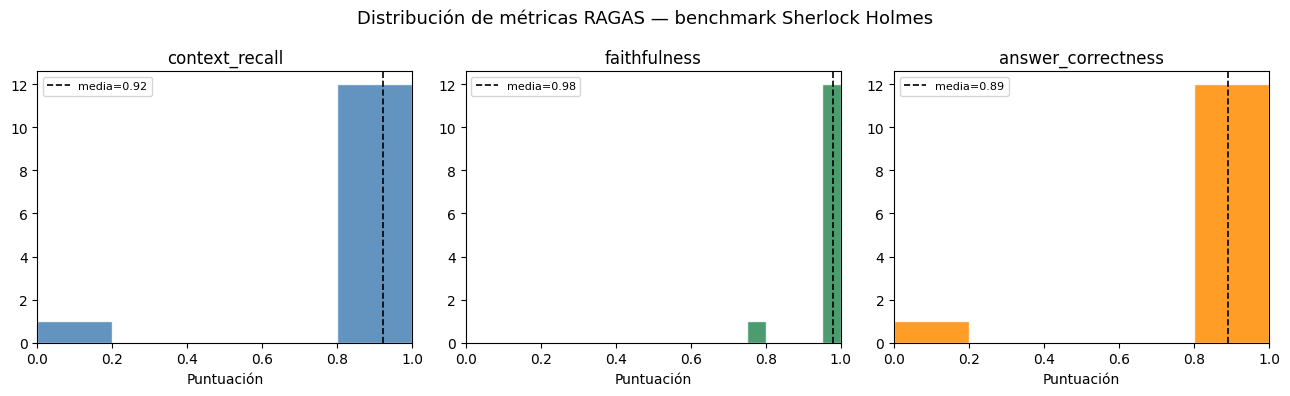

In [13]:
import matplotlib.pyplot as plt

metrics = ['context_recall', 'faithfulness', 'answer_correctness']
colors  = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Distribución de métricas RAGAS — benchmark Sherlock Holmes', fontsize=13)

for ax, metric, color in zip(axes, metrics, colors):
    ax.hist(scored_df[metric].dropna(), bins=5, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(scored_df[metric].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'media={scored_df[metric].mean():.2f}')
    ax.set_title(metric)
    ax.set_xlabel('Puntuación')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

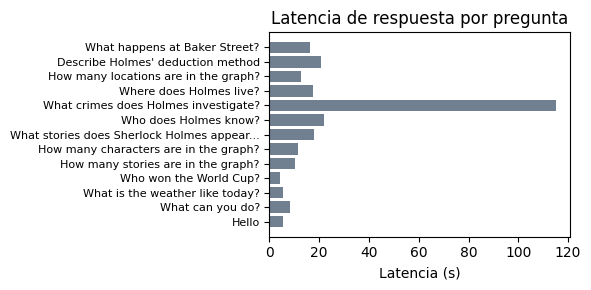

In [14]:
# Distribución de latencia
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(range(len(scored_df)), scored_df['latency'], color='slategray')
ax.set_yticks(range(len(scored_df)))
ax.set_yticklabels(
    [q[:40] + '...' if len(q) > 40 else q for q in scored_df['question']],
    fontsize=8
)
ax.set_xlabel('Latencia (s)')
ax.set_title('Latencia de respuesta por pregunta')
plt.tight_layout()
plt.show()

### 4.2 Mejor y peor caso por answer_correctness

Inspeccionar los extremos ayuda a diagnosticar *por qué* falla el sistema:
- `context_recall` bajo → el recuperador no encontró los chunks relevantes → ajustar `chunk_size` o `top_k`
- `faithfulness` bajo → el LLM alucinó → mejorar el prompt de respuesta o añadir instrucciones de anclaje
- `answer_correctness` bajo con `faithfulness` alto → el contexto recuperado era incompleto

In [15]:
def show_case(label, row):
    print(f"{'='*70}")
    print(label)
    print(f"{'='*70}")
    print(f"Question        : {row['question']}")
    print(f"Ground truth    : {str(row['ground_truth'])[:200]}")
    print(f"Answer          : {str(row['answer'])[:200]}")
    print(f"answer_correctness : {row['answer_correctness']:.3f}")
    print(f"context_recall     : {row['context_recall']:.3f}")
    print(f"faithfulness       : {row['faithfulness']:.3f}")
    print()

best_idx  = scored_df['answer_correctness'].idxmax()
worst_idx = scored_df['answer_correctness'].idxmin()

show_case("MEJOR CASO",  scored_df.loc[best_idx])
show_case("PEOR CASO", scored_df.loc[worst_idx])

MEJOR CASO
Question        : Hello
Ground truth    : Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.
Answer          : ¡Hola! Soy un asistente de conocimiento especializado en las historias de Sherlock Holmes de Arthur Conan Doyle. Puedo responder preguntas sobre personajes, ubicaciones, crímenes, deducciones, objetos
answer_correctness : 1.000
context_recall     : 1.000
faithfulness       : 1.000

PEOR CASO
Question        : Where does Holmes live?
Ground truth    : house; Doctors' Commons
Answer          : Esta información no se encuentra en la base de conocimiento.
answer_correctness : 0.000
context_recall     : 0.000
faithfulness       : 1.000



### 4.3 Correlación entre métricas

¿Son las tres métricas independientes o tienden a moverse juntas?
Una correlación fuerte entre `context_recall` y `answer_correctness` confirmaría
que la calidad de la recuperación es el principal cuello de botella.

In [16]:
corr = scored_df[metrics].corr()
print("Correlación de Pearson entre métricas:")
print(corr.round(3))

Correlación de Pearson entre métricas:
                    context_recall  faithfulness  answer_correctness
context_recall               1.000        -0.083               0.972
faithfulness                -0.083         1.000               0.099
answer_correctness           0.972         0.099               1.000


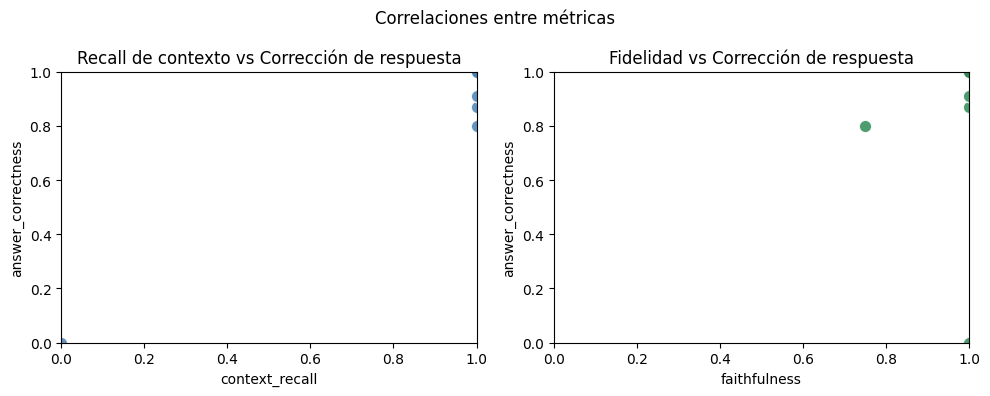

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(scored_df['context_recall'], scored_df['answer_correctness'],
                color='steelblue', edgecolors='white', s=80, alpha=0.85)
axes[0].set_xlabel('context_recall')
axes[0].set_ylabel('answer_correctness')
axes[0].set_title('Recall de contexto vs Corrección de respuesta')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].scatter(scored_df['faithfulness'], scored_df['answer_correctness'],
                color='seagreen', edgecolors='white', s=80, alpha=0.85)
axes[1].set_xlabel('faithfulness')
axes[1].set_ylabel('answer_correctness')
axes[1].set_title('Fidelidad vs Corrección de respuesta')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle('Correlaciones entre métricas', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Guardar resultados

In [18]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"../data/evaluation_results_{timestamp}.csv"
scored_df.to_csv(out_path, index=False)
print(f"Resultados guardados en {out_path}")

Resultados guardados en ../data/evaluation_results_20260505_130733.csv


In [19]:
neo4j.close()